
Name:- Budike Meeraj Kumar

Course:- MSc Data Science, AI and Digital Business

Module:- M508C Big Data Analytics

# NLP Pipeline on YouTube Comments Sentiment Analysis

## 1. Introduction

Now a days social media platforms have become major sources for public voice, with YouTube being one of the most popular applications for sharing videos and engaging through comments. Billions of users interact daily by posting comments that reflect opinions, attitude and emotions. Analyzing these comments manually is difficult as they are in large volume and diverse writing styles. In this project we will focus on applying NLP techniques to classify YouTube comments based on their sentiment, enabling better understanding of audience reactions and improving digital content strategies.

## 2. Business Problem

YouTube content creators and brand marketing companies depend more on audience feedback to understand how viewers are receiving their content. And manually reading thousands of comments is time consuming and practically not possible. Without this analysis businesses may miss important insights such as:

* Customer dissatisfaction or negative trends on their content
* Positive engagement opportunities
* Reputation risks from harmful or negative discussions
* Suggestions and feedback

A lack of structured sentiment insights limits decision-making for content improvement, brand perception monitoring, and audience engagement strategies.

## 3. Problem Statement                                                             
At present here is no automated mechanism to identify or analyze the sentiment efficiently in large volumes. As a result, valuable feedback remains unstructured and difficult to interpret. The project aim is to develop an NLP based sentiment classification model structure which capable of categorizing YouTube comments into positive, negative, or neutral classes accurately. The solution Will also handle with informal language, slang, emojis and varied writing patterns typically found on social media.


## 4. Project Objective


#A)Primary Objective

To build and evaluate a machine learning/NLP model that classifies YouTube

comments into sentiment categories (positive, negative, neutral).

#B)Secondary Objectives

* To preprocess and clean raw YouTube comments for sentiment analysis.

* To explore and compare different NLP techniques and algorithms

* To visualize sentiment distribution and insights from YouTube comments data.

* To provide a system that helps creators or businesses interpret audience feedback more efficiently.

* To recommend improvements based on sentiment insights.




Dataset Link : https://www.kaggle.com/datasets/amaanpoonawala/youtube-comments-sentiment-dataset

**Phase 1: Data Acquisition**

In [ ]:
!pip install transformers torch datasets
!pip install spacy
!python -m spacy download en_core_web_sm
!pip install emoji
!pip install textblob
!python -m textblob.download_corpora
!pip install gensim
!pip install torch scikit-learn
!pip install accelerate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 88.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 

This project focuses on YouTube Comments Sentiment Analysis using different set of Python libraries for data processing and analysis. NumPy and Pandas are used to clean, organize, and manage large scale comment datasets & Matplotlib and Seaborn used clear visualizations of sentiment distribution. Natural Language Processing techniques such as text cleaning, tokenization, lemmatization, stopword removal, part-of-speech tagging, and Named Entity Recognition are implemented using NLTK and spaCy. For feature extraction and modeling, TF-IDF, embeddings are used. Sentiment classification is performed using traditional machine learning models like Logistic Regression and transformer-based models such as fined tuned BERT. Model performance is assessed using scikit-learn evaluation metrics, WordCloud visualizations for handling spelling variations, and warnings suppressed for clean and readable outputs.

In [ ]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


import spacy
import re
import nltk
from nltk.corpus import stopwords


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder


from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from transformers import Trainer, TrainingArguments


import warnings
warnings.filterwarnings("ignore")

Uploaded the dataset here and took sample form it because it very big dataset and unable perform required operations on my current system.

In [ ]:
df = pd.read_csv("/content/youtube_comments_cleaned.csv", encoding='latin1')

In [ ]:
#dataset info
print("Dataset shape:", df.shape)
print("Columns:", df.columns)
print("\nNull values per column:\n", df.isnull().sum())

# sample of 5000 rows
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)

#sample
print("Sample dataset shape:", df_sample.shape)
df_sample.head()

Dataset shape: (168129, 12)
Columns: Index(['CommentID', 'VideoID', 'VideoTitle', 'AuthorName', 'AuthorChannelID',
       'CommentText', 'Sentiment', 'Likes', 'Replies', 'PublishedAt',
       'CountryCode', 'CategoryID'],
      dtype='object')

Null values per column:
 CommentID            0
VideoID              0
VideoTitle           0
AuthorName         105
AuthorChannelID      1
CommentText          1
Sentiment            1
Likes                1
Replies              1
PublishedAt          1
CountryCode          1
CategoryID           1
dtype: int64
Sample dataset shape: (5000, 12)


,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID
0,Ugxk9Qj1zBy7G8Wnk414AaABAg_aug,2dYBxD_uius,First to see Nvidia 5090 in person!,AugmentedUser,AugmentedCID,"A 5070 with 12GB of VRAM is a joke, and I have...",Negative,0.0,0.0,2025-02-04 14:53:30,US,28.0
1,UgxabuFFyYa0d0_HZ_V4AaABAg_aug,gDu9kVy17Vw,Vast 65 km Russian military convoy advances to...,AugmentedUser,AugmentedCID,Unbelievable. This isn't Syria; this is Ukrain...,Neutral,0.0,0.0,2025-02-05 04:57:59,DE,25.0
2,UgxWvIggRKrxaUX95hV4AaABAg,OsuBmAVqR7I,L.A. Fires: Why Did the Fire Hydrants Run Dry?...,@SevdeOlcay,UC6DSxjkb3sCdac_MSZEYffA,Glad I got into Adaxum during the presale. The...,Neutral,0.0,0.0,2025-01-14 13:48:04,NZ,25.0
3,UgycZlNcpJTW-ci9Dzx4AaABAg_aug,zcDSGCBWf1g,WHY IS AMIR ALWAYS SAYING “SIR”? 🙏😭,AugmentedUser,AugmentedCID,"Amir didn't say ""Sir"" for 2 minutes and los an...",Negative,0.0,0.0,2025-02-04 13:00:26,US,15.0
4,UgyEeTBi_2rv1JJtv6R4AaABAg,TGYXtXVlekA,WAR!! WALL STREET vs. MAIN STREET! | Louder wi...,@strydyrhellzrydyr1345,UC5fASU5n8-YJTybetKcoq6w,It's been 2 years.... Still no new jobs,Negative,0.0,0.0,2022-10-30 12:54:40,US,25.0


In [ ]:
# sample of 5000 rows
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)


In [ ]:
print("Dataset Info ")
df_sample.info()

Dataset Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CommentID        5000 non-null   object 
 1   VideoID          5000 non-null   object 
 2   VideoTitle       5000 non-null   object 
 3   AuthorName       4997 non-null   object 
 4   AuthorChannelID  5000 non-null   object 
 5   CommentText      5000 non-null   object 
 6   Sentiment        5000 non-null   object 
 7   Likes            5000 non-null   float64
 8   Replies          5000 non-null   float64
 9   PublishedAt      5000 non-null   object 
 10  CountryCode      5000 non-null   object 
 11  CategoryID       5000 non-null   float64
dtypes: float64(3), object(9)
memory usage: 468.9+ KB


In [ ]:
print("Statistical Summary")
df_sample.describe()

Statistical Summary


,Likes,Replies,CategoryID
count,5000.000000,5000.000000,5000.000000
mean,99.160200,2.355000,23.133000
std,1518.965483,18.208308,6.349565
min,0.000000,0.000000,1.000000
25%,0.000000,0.000000,24.000000
50%,0.000000,0.000000,25.000000
75%,2.000000,0.000000,27.000000
max,92934.000000,683.000000,28.000000


In [ ]:
print("Columns in the dataset ")
print(df_sample.columns.tolist())

Columns in the dataset 
['CommentID', 'VideoID', 'VideoTitle', 'AuthorName', 'AuthorChannelID', 'CommentText', 'Sentiment', 'Likes', 'Replies', 'PublishedAt', 'CountryCode', 'CategoryID']


**Phase 2: Text Cleaning**

In [ ]:
# Load model
nlp = spacy.load("en_core_web_sm")


Define Cleaning Function

In [ ]:
stopwords = spacy.lang.en.stop_words.STOP_WORDS

def clean_text_spacy(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc
              if token.text not in stopwords
              and token.is_alpha]
    return " ".join(tokens)


In [ ]:
df_sample['clean_comment'] = df_sample['CommentText'].apply(clean_text_spacy)
df_sample[['CommentText', 'clean_comment']].head()

,CommentText,clean_comment
0,This perfectly captures the vibe of my discuss...,perfectly capture vibe discussion auto shop ow...
1,Progressive policies did this.,progressive policy
2,The mediaâs sycophancy is nauseating.,sycophancy nauseate
3,Hey @hitesh It was all there in version 5 too ...,hey version refined easy understand
4,I don't believe it; total fabrication.,believe total fabrication


Define Function to Remove Emojis, Hashtags, Mentions, Extra Whitespace

In [ ]:
def remove_extra_elements(text):
    # Remove mentions
    text = re.sub(r"@\w+", "", text)
    # Remove hashtags
    text = re.sub(r"#\w+", "", text)
    # Remove emojis
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags
                               u"\U00002700-\U000027BF"  # dingbats
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [ ]:
df_sample['clean_comment'] = df_sample['clean_comment'].apply(remove_extra_elements)
df_sample[['CommentText', 'clean_comment']].head()


,CommentText,clean_comment
0,This perfectly captures the vibe of my discuss...,perfectly capture vibe discussion auto shop ow...
1,Progressive policies did this.,progressive policy
2,The mediaâs sycophancy is nauseating.,sycophancy nauseate
3,Hey @hitesh It was all there in version 5 too ...,hey version refined easy understand
4,I don't believe it; total fabrication.,believe total fabrication


In [ ]:

from textblob import TextBlob

Define Function for Repeated Character Normalization and spell correction

In [ ]:
def normalize_repeated_chars(text):
    pattern = re.compile(r'(.)\1{2,}', re.DOTALL)  # matchs any char repeated more than 2
    return pattern.sub(r'\1\1', text)
def correct_spelling(text):
    return str(TextBlob(text).correct())


In [ ]:
def advanced_clean_text(text, do_spell_correction=False):
    text = normalize_repeated_chars(text)
    # Spell correction
    if do_spell_correction:
        text = correct_spelling(text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:
# Without spell correction
df_sample['clean_comment'] = df_sample['clean_comment'].apply(lambda x: advanced_clean_text(x))
df_sample[['CommentText', 'clean_comment']].head()


,CommentText,clean_comment
0,This perfectly captures the vibe of my discuss...,perfectly capture vibe discussion auto shop ow...
1,Progressive policies did this.,progressive policy
2,The mediaâs sycophancy is nauseating.,sycophancy nauseate
3,Hey @hitesh It was all there in version 5 too ...,hey version refined easy understand
4,I don't believe it; total fabrication.,believe total fabrication


**Phase 3:  EDA**

Class Balance: distribution of sentiment labels (Positive, Negative, Neutral)

Class Distribution:
 Sentiment
Negative    1690
Neutral     1660
Positive    1650
Name: count, dtype: int64


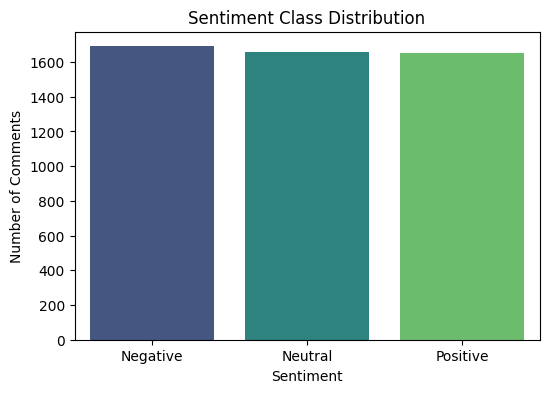

In [ ]:
# Count of each sentiment
class_counts = df_sample['Sentiment'].value_counts()
print("Class Distribution:\n", class_counts)
# Bar plot
plt.figure(figsize=(6,4))
sns.countplot(data=df_sample, x='Sentiment', palette='viridis')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()


Calculate Comment Length and coment word count visualization

In [ ]:
# Add a new column for comment length (number of characters)
df_sample['comment_length'] = df_sample['clean_comment'].apply(len)
# calculate number of words
df_sample['comment_word_count'] = df_sample['clean_comment'].apply(lambda x: len(x.split()))
df_sample[['clean_comment', 'comment_length', 'comment_word_count']].head()


,clean_comment,comment_length,comment_word_count
0,perfectly capture vibe discussion auto shop ow...,87,12
1,progressive policy,18,2
2,sycophancy nauseate,19,2
3,hey version refined easy understand,35,5
4,believe total fabrication,25,3


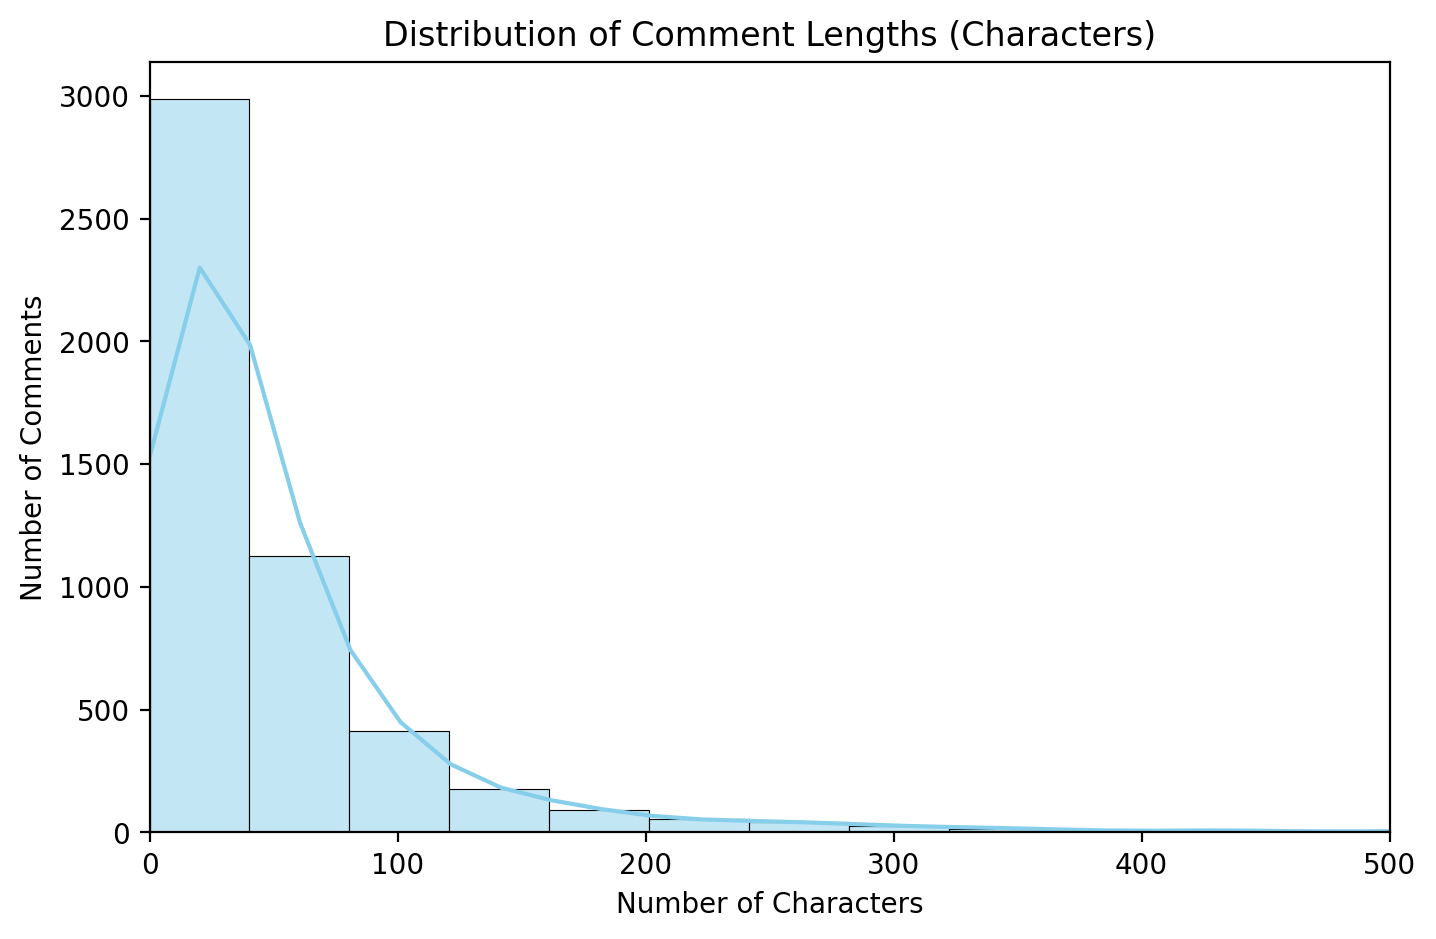

In [ ]:
plt.figure(figsize=(8,5),dpi=200)
sns.histplot(df_sample['comment_length'], bins=100, kde=True, color='skyblue')
plt.title("Distribution of Comment Lengths (Characters)")
plt.xlabel("Number of Characters")
plt.xlim(0, 500)
plt.ylabel("Number of Comments")
plt.show()


Word count distribution

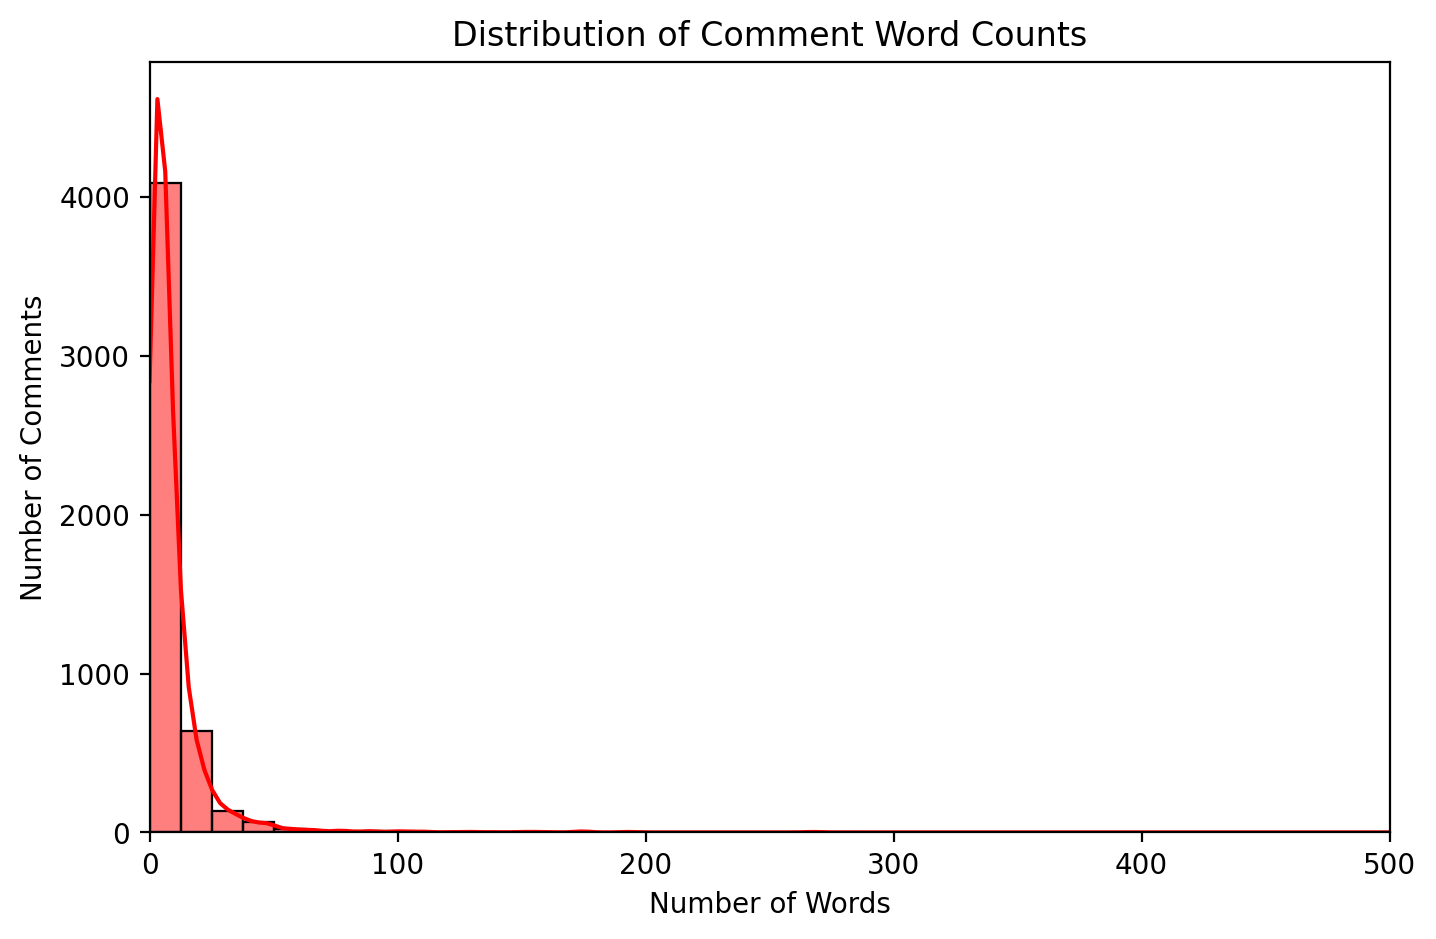

In [ ]:
df_sample['comment_word_count'] = df_sample['clean_comment'].apply(lambda x: len(x.split()))
df_sample[['clean_comment', 'comment_word_count']].head()
plt.figure(figsize=(8,5),dpi=200)
sns.histplot(df_sample['comment_word_count'], bins=50, kde=True, color='red')
plt.title("Distribution of Comment Word Counts")
plt.xlabel("Number of Words")
plt.xlim(0, 500)
plt.ylabel("Number of Comments")
plt.show()


WordCloud for most frequent words per sentiment

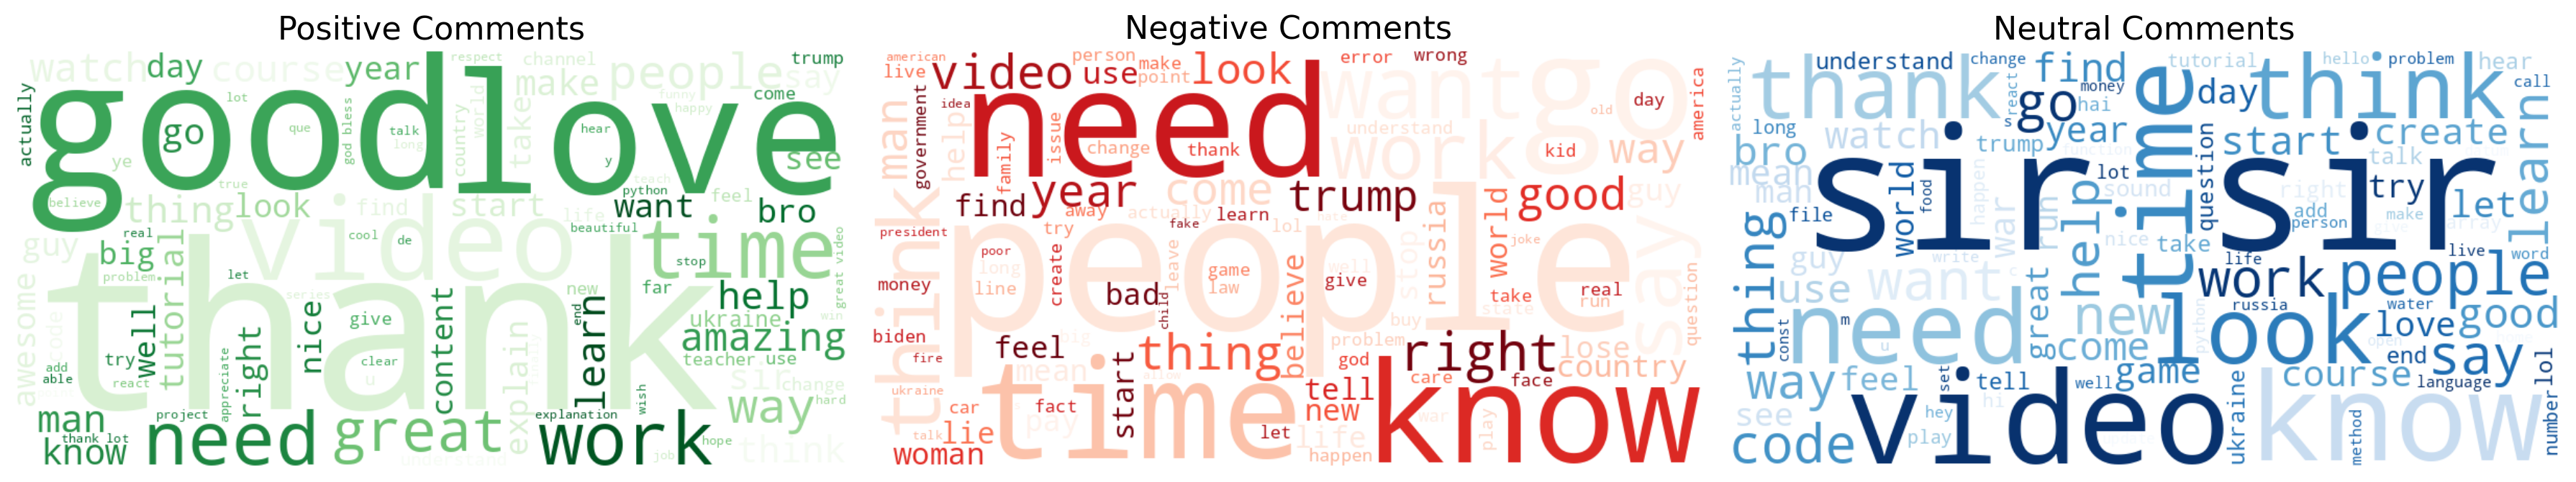

In [ ]:
sentiments = ['Positive', 'Negative', 'Neutral']
colormaps = {    'Positive': 'Greens','Negative': 'Reds','Neutral': 'Blues'}


fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=200)


for ax, sentiment in zip(axes, sentiments):
    # Combine all cleaned comments for this sentiment
    text = " ".join(df_sample[df_sample['Sentiment'] == sentiment]['clean_comment'].tolist())

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100,
        colormap=colormaps[sentiment]
    ).generate(text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"{sentiment} Comments", fontsize=16)

plt.tight_layout()
plt.show()


Top n-grams (bigrams/trigrams) for each sentiment

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
def get_top_ngrams(corpus, ngram_range=(2,2), top_n=10):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(corpus)

    # Sum up the counts of each n-gram
    ngram_counts = X.sum(axis=0)

    # Map n-gram to count
    ngram_freq = [(ngram, ngram_counts[0, idx]) for ngram, idx in vectorizer.vocabulary_.items()]

    # Sort by frequency
    ngram_freq = sorted(ngram_freq, key=lambda x: x[1], reverse=True)

    return ngram_freq[:top_n]


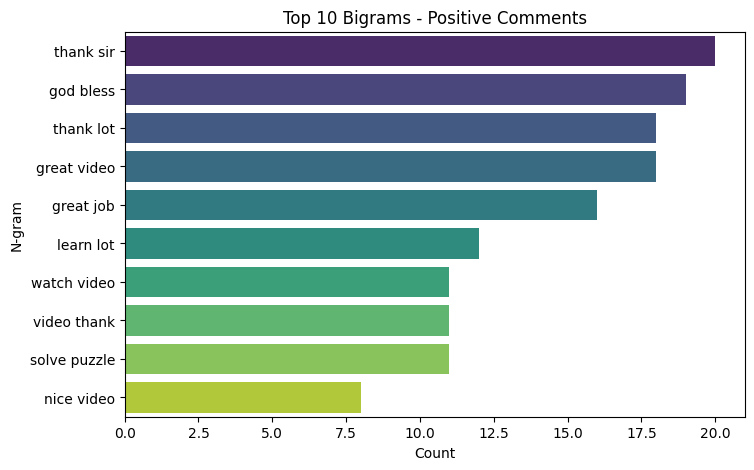

In [ ]:
def plot_top_ngrams(ngrams, title):
    ngram_df = pd.DataFrame(ngrams, columns=['ngram', 'count'])
    plt.figure(figsize=(8,5))
    sns.barplot(x='count', y='ngram', data=ngram_df, palette='viridis')
    plt.title(title)
    plt.xlabel('Count')
    plt.ylabel('N-gram')
    plt.show()

positive_bigrams = get_top_ngrams(df_sample[df_sample['Sentiment'] == 'Positive']['clean_comment'].tolist(), ngram_range=(2,2), top_n=10)
plot_top_ngrams(positive_bigrams, "Top 10 Bigrams - Positive Comments")


**Phase 4: Text Preprocessing**

1. Tokenization

In [ ]:
def tokenize_text(text):
    doc = nlp(text)
    tokens = [token.text for token in doc if not token.is_punct and not token.is_space]
    return tokens


In [ ]:
# Create a new column for tokenized comments
df_sample['tokenized_comment'] = df_sample['clean_comment'].apply(tokenize_text)
df_sample[['clean_comment', 'tokenized_comment']].head()


,clean_comment,tokenized_comment
0,perfectly capture vibe discussion auto shop ow...,"[perfectly, capture, vibe, discussion, auto, s..."
1,progressive policy,"[progressive, policy]"
2,sycophancy nauseate,"[sycophancy, nauseate]"
3,hey version refined easy understand,"[hey, version, refined, easy, understand]"
4,believe total fabrication,"[believe, total, fabrication]"


2. Lemmatization

In [ ]:
def lemmatize_text(text):
    doc = nlp(text)
    lemmatized_tokens = [token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    return " ".join(lemmatized_tokens)
# Create a new column for lemmatized comments
df_sample['lemmatized_comment'] = df_sample['clean_comment'].apply(lemmatize_text)
df_sample[['clean_comment', 'lemmatized_comment']].head()


,clean_comment,lemmatized_comment
0,perfectly capture vibe discussion auto shop ow...,perfectly capture vibe discussion auto shop ow...
1,progressive policy,progressive policy
2,sycophancy nauseate,sycophancy nauseate
3,hey version refined easy understand,hey version refine easy understand
4,believe total fabrication,believe total fabrication


3.Stopword removal

In [ ]:
from spacy.lang.en.stop_words import STOP_WORDS
def remove_stopwords(text):
    doc = nlp(text.lower())
    tokens = [token.text for token in doc if token.text not in STOP_WORDS and token.is_alpha]
    return " ".join(tokens)
# Create a new column with stopwords removed
df_sample['no_stopwords_comment'] = df_sample['clean_comment'].apply(remove_stopwords)
df_sample[['clean_comment', 'no_stopwords_comment']].head()


,clean_comment,no_stopwords_comment
0,perfectly capture vibe discussion auto shop ow...,perfectly capture vibe discussion auto shop ow...
1,progressive policy,progressive policy
2,sycophancy nauseate,sycophancy nauseate
3,hey version refined easy understand,hey version refined easy understand
4,believe total fabrication,believe total fabrication


**Phase 5: Feature Engineering**

1. TF-IDF

In this step, we extract TF-IDF (Term Frequency–Inverse Document Frequency) features from the cleaned text to represent news articles numerically for model training.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Initialize TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
# Assuming 'clean_comment' column contains cleaned and lemmatized text
X_tfidf = tfidf_vectorizer.fit_transform(df_sample['clean_comment'])

print("TF-IDF feature matrix shape:", X_tfidf.shape)
# Convert sparse matrix to DataFrame for inspection
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

tfidf_df.head()

TF-IDF feature matrix shape: (5000, 5000)


,aa,aaj,aama,aameen,aand,aankh,aap,aapke,aapki,aapne,...,zelda,zelenskiy,zelensky,zelenskyy,zero,zionist,zone,zuckerberg,ðº,ðºð
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


2. BERT Embeddings: use Hugging Face transformer (bert-base-uncased) for deep learning model

Pre-trained BERT tokenizer and model

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
def get_bert_embeddings(text_list, max_length=128):
    encoded_input = tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

    # Get hidden states from BERT
    with torch.no_grad():
        output = model(**encoded_input)

    # Use the token embedding as sentence representation
    embeddings = output.last_hidden_state[:, 0, :]

    return embeddings
sample_texts = df_sample['clean_comment'].head(10).tolist()
bert_embeddings = get_bert_embeddings(sample_texts)

print("BERT embeddings shape:", bert_embeddings.shape)


BERT embeddings shape: torch.Size([10, 768])


**Split Dataset**

In [ ]:
from sklearn.preprocessing import LabelEncoder

X = X_tfidf
y = df_sample['Sentiment']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=101, stratify=y_encoded)

**Phase 6: Modeling**

1. Logistic Regression (TF-IDF)

In [ ]:
# TF-IDF features from previous step
X = X_tfidf
y = df_sample['Sentiment']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Converts 'Positive'/'Negative'/'Neutral' to 0,1,2


In [ ]:
# Initialize and train
lr_model = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto')
lr_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000, multi_class='auto')

In [ ]:
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.5720
Precision: 0.5797
Recall: 0.5720
F1 Score: 0.5741


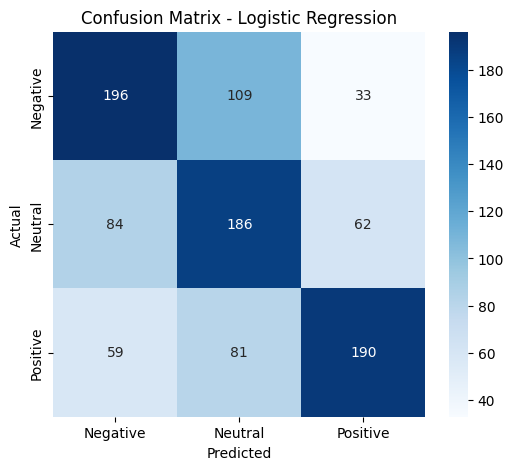

In [ ]:
# Predict on test set
y_pred = lr_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


BERT Model

In [ ]:
le = LabelEncoder()
df_sample['label'] = le.fit_transform(df_sample['Sentiment'])  # 0,1,2

# Split dataset
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_sample['clean_comment'], df_sample['label'], test_size=0.2, random_state=42, stratify=df_sample['label'])


In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenization and encoding
max_length = 128

def encode_texts(texts):
    return tokenizer(
        texts.tolist(),
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

train_encodings = encode_texts(train_texts)
test_encodings = encode_texts(test_texts)


In [ ]:
class CommentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

train_dataset = CommentDataset(train_encodings, train_labels)
test_dataset = CommentDataset(test_encodings, test_labels)


In [ ]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.CrossEntropyLoss()


In [ ]:
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/3, Loss: 0.9380
Epoch 2/3, Loss: 0.7533
Epoch 3/3, Loss: 0.5368


Accuracy: 0.608
F1 Score: 0.6096007736820522

Classification Report:
               precision    recall  f1-score   support

    Negative       0.68      0.53      0.60       338
     Neutral       0.51      0.67      0.58       332
    Positive       0.68      0.62      0.65       330

    accuracy                           0.61      1000
   macro avg       0.63      0.61      0.61      1000
weighted avg       0.63      0.61      0.61      1000



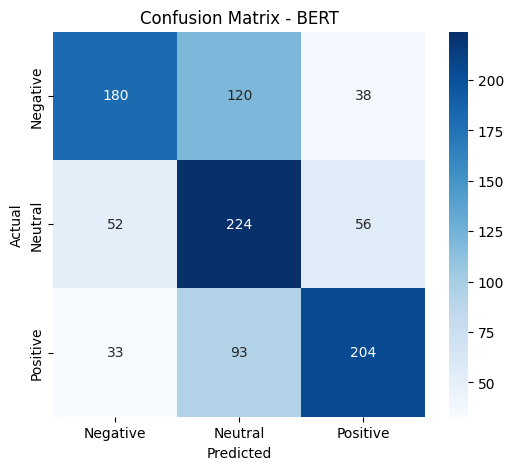

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

# Metrics
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds, average='weighted'))
print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - BERT')
plt.show()


**3) Fine-Tuned Transformer for YouTube Sentiment Analysis**

In [ ]:
texts = df_sample['clean_comment'].astype(str).tolist()

label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df_sample['Sentiment'])

num_labels = len(label_encoder.classes_)
print(label_encoder.classes_)


['Negative' 'Neutral' 'Positive']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


In [ ]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


In [ ]:
trainer.train()


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.851079,0.616000,0.613952
2,0.811200,0.834823,0.654000,0.656287
3,0.811200,0.915312,0.654000,0.655548


TrainOutput(global_step=750, training_loss=0.7367192789713541, metrics={'train_runtime': 389.7206, 'train_samples_per_second': 30.791, 'train_steps_per_second': 1.924, 'total_flos': 789340253184000.0, 'train_loss': 0.7367192789713541, 'epoch': 3.0})

**Evaluation**

This output shows the evaluation metrics of the fine-tuned BERT model on the test dataset. The metrics include loss, accuracy, precision, recall, and F1-score. Additional details such as evaluation runtime, samples per second, and the epoch number provide insights into the evaluation efficiency and dataset throughput.

In [ ]:
results = trainer.evaluate()
print(results)


{'eval_loss': 0.834822952747345, 'eval_accuracy': 0.654, 'eval_f1': 0.6562867647116173, 'eval_runtime': 6.4124, 'eval_samples_per_second': 155.949, 'eval_steps_per_second': 9.825, 'epoch': 3.0}


Confusion Matrix

This heatmap displays the confusion matrix for the Fine Tuned model, showing how many instances were correctly or incorrectly classified as positive,negative and neutral comments. The diagonal values represent correctly predicted samples, while off-diagonal values indicate misclassifications. This visualization provides a clear understanding of the model’s performance across the classes.

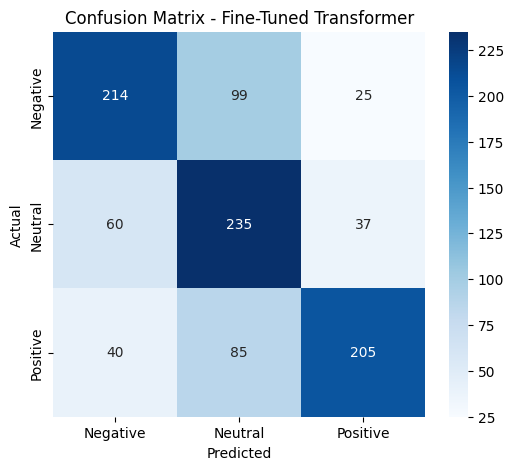

In [ ]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)

    # Confusion matrix
    cm = confusion_matrix(labels, predictions)

    return {'accuracy': acc,'f1': f1,'precision': precision,'recall': recall,'confusion_matrix': cm.tolist()}

# Get predictions from the fine-tuned model
predictions_output = trainer.predict(test_dataset)
y_pred_logits = predictions_output.predictions
y_true = predictions_output.label_ids
y_pred = np.argmax(y_pred_logits, axis=-1)

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Fine-Tuned Transformer')
plt.show()

Experimental Comparison metrics

For simple visualization comparing the accuracy, precision, recall, F1-score of Logistic Regression (TF-IDF),Fine-Tuned Transformer.

In [ ]:
data = {
    "Model": ["Logistic Regression", "BERT", "Fine-tuned BERT"],
    "Accuracy": [0.5720, 0.608, 0.654],
    "Precision": [0.5797, 0.63, 0.675],
    "Recall": [0.5720, 0.61, 0.665],
    "F1 Score": [0.5741, 0.6096, 0.6563]
}

df = pd.DataFrame(data)
print(df)



                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.572     0.5797   0.572    0.5741
1                 BERT     0.608     0.6300   0.610    0.6096
2      Fine-tuned BERT     0.654     0.6750   0.665    0.6563


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.572,0.5797,0.572,0.5741
1,BERT,0.608,0.6300,0.610,0.6096
2,Fine-tuned BERT,0.654,0.6750,0.665,0.6563



**Understandings of data** : Learned how positive, negative, and neutral comments differ in tone, word usage, and emojis, helping businesses understand audience reactions quickly.

**Importance of Deep Text Cleaning:** Understood that proper text cleaning and preprocessing greatly improves model accuracy when working with noisy social media comments.

**Feature Engineering:** Observed that TF-IDF works well for keyword-based sentiment detection, while BERT captures deeper context and meaning in comments.

**Model Selection Insights:** Learned that transformer-based models like BERT outperform traditional models for sentiment analysis on real-world text.

**Strategy:** Gained insight into how sentiment results can guide content improvement and audience engagement decisions.

**Decision-Making Platforms:** Learned how automated sentiment analysis helps brands and platforms monitor feedback and manage online communities effectively.

# Conclusion:

This is my NLP pipeline on sentiment analysis on youtube comments. In this the data is cleaned and analyzed and explored it using clear visualizations like class balance and word clouds. I have worked on models like Logistics Regression using TF-IDDF,BERT and Fine-Tuned BERT transformer.The Fine-Tuned transformer model performed better compare to all the models and my data set was too big to run one my system thats the reson I took sample and low performances of the model. TF-IDF worked well but transformers gave more accurate results. The pipeline is built efficient, scalable and can be extended to analyze the large datasets or realtime YouTube comments.Overall, this helps companies quickely understand the opinions and improve their content decisions.